In [5]:
import os
from dotenv import load_dotenv
import mysql.connector
import pandas as pd

# Load the .env file
load_dotenv()

# Connect using environment variables
conn = mysql.connector.connect(
    host=os.getenv("DB_HOST") or "127.0.0.1",
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME"),
    unix_socket=None
)

# Query and show data
query = "SELECT * FROM customers1"
df = pd.read_sql(query, conn)
df.head
df.dtypes

C:\Users\benma\AppData\Local\Temp\ipykernel_5180\1626928165.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [6]:
# Create a separate copy for modeling
df_model = df.drop(columns=["customerID"])
df_model = pd.get_dummies(df_model, drop_first=True)

# Convert any boolean to int 
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

In [7]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check if there are other columns that need conversion
# Assuming 'MonthlyCharges' might also be a column needing conversion
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')



In [8]:
# Fill NaN values with the median of each column
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    df[column] = df[column].fillna(df[column].median())


In [9]:
print("Remaining NaN counts in each column:")
print(df.isna().sum())

Remaining NaN counts in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
# Convert Yes/No to 0/1
yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in yes_no_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

# Keep original df for Power BI use
df_visual = df.copy()

In [11]:
# One-hot encode all categorical columns (like gender, contract, etc.)
df_encoded = pd.get_dummies(df, drop_first=True)

# Check the new shape and preview
print("Encoded shape:", df_encoded.shape)
df_encoded.head()



Encoded shape: (7032, 7062)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,False,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,False,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,False,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


In [12]:
# Define the target column
y = df_encoded["Churn_Yes"] if "Churn_Yes" in df_encoded.columns else df_encoded["Churn"]

# Define features by dropping the target column
X = df_encoded.drop(columns=["Churn", "Churn_Yes"], errors='ignore')


In [13]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [14]:
# Drop columns not useful for model
df_model = df.drop(columns=["customerID"])

# One-hot encode all categorical columns for model
df_model = pd.get_dummies(df_model, drop_first=True)

# Ensure all booleans are converted to integers
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)


C:\Users\benma\AppData\Local\Temp\ipykernel_5180\148767781.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Churn"], palette="pastel")


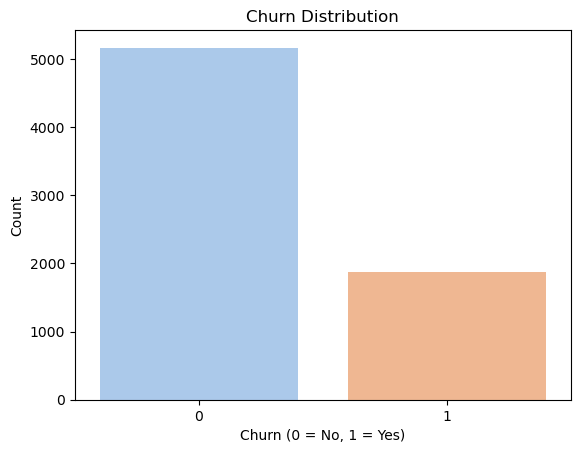

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["Churn"], palette="pastel")
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

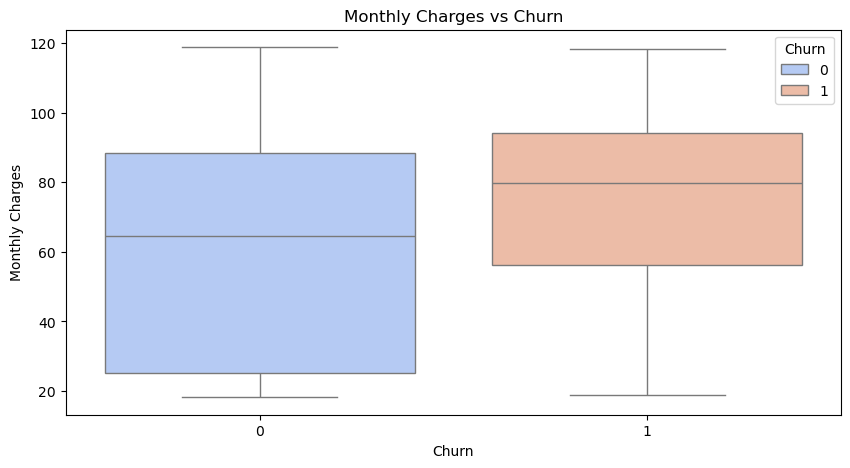

In [16]:
# Temporarily add the target back to X for plotting
X_plot = X.copy()
X_plot["Churn"] = y  # y is already your 0/1 target

# Plot using X_plot
plt.figure(figsize=(10, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", hue="Churn", data=X_plot, palette="coolwarm", dodge=False)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


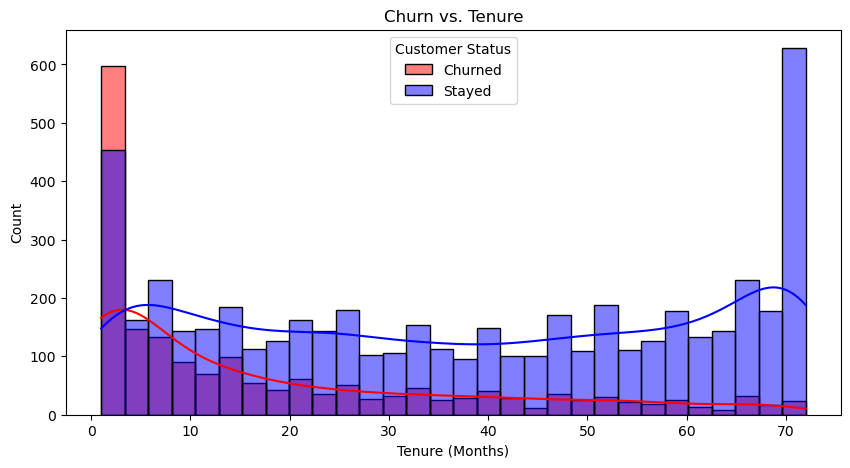

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the size of the plot
plt.figure(figsize=(10, 5))

# Plotting two categories with different colors and labels
sns.histplot(data=df[df['Churn'] == 1], x='tenure', bins=30, color='red', label='Churned', kde=True)
sns.histplot(data=df[df['Churn'] == 0], x='tenure', bins=30, color='blue', label='Stayed', kde=True)

# Adding labels and title
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.title('Churn vs. Tenure')

# Adding the legend explicitly
plt.legend(title='Customer Status')  # Ensure this is after all plots

# Show the plot
plt.show()


In [18]:
from sklearn.model_selection import train_test_split

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (5625, 7061)
Test shape: (1407, 7061)


In [19]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to training data
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_resampled.value_counts())

model = RandomForestClassifier(random_state=42)

# Now train the model on the balanced data
model.fit(X_resampled, y_resampled)




Before SMOTE: Churn
0    4130
1    1495
Name: count, dtype: int64
After SMOTE: Churn
1    4130
0    4130
Name: count, dtype: int64


RandomForestClassifier(random_state=42)

In [20]:
import pandas as pd

# Create a Series of feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)

# Sort them from most to least important
importances = importances.sort_values(ascending=False)

# View top 10 features
print(importances.head(10))


TotalCharges                      0.088534
tenure                            0.081982
MonthlyCharges                    0.068508
PaymentMethod_Electronic check    0.063957
InternetService_Fiber optic       0.034953
Contract_Two year                 0.028215
Dependents                        0.027977
Partner                           0.025264
Contract_One year                 0.017386
MultipleLines_Yes                 0.015377
dtype: float64


In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on test set
y_pred = model.predict(X_test)

# Print results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7867803837953091

Confusion Matrix:
 [[890 143]
 [157 217]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86      1033
           1       0.60      0.58      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.72      1407
weighted avg       0.78      0.79      0.79      1407



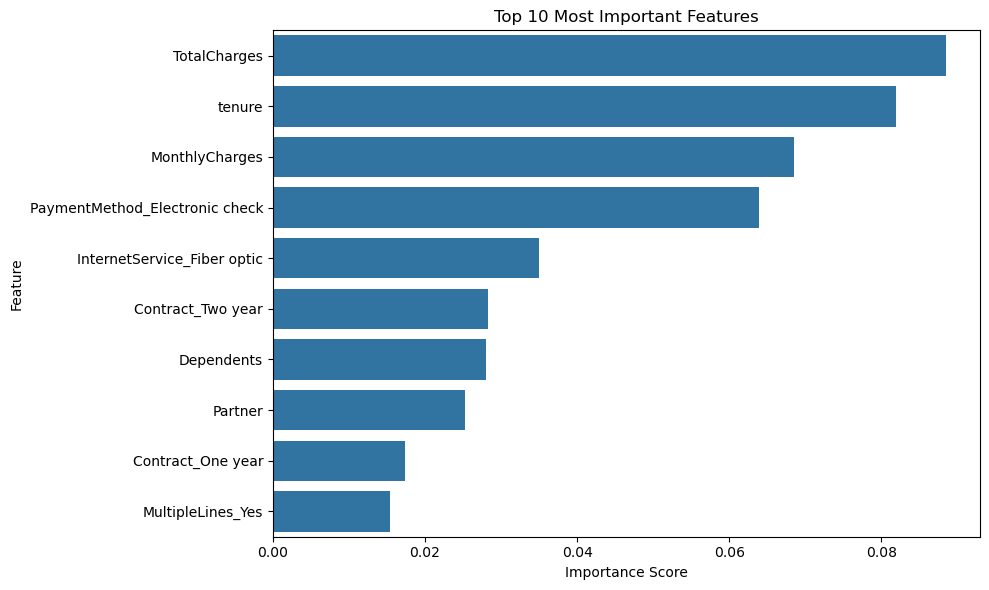

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10])
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [23]:
print(importances.sort_values())


customerID_9957-YODKZ             0.000000
customerID_4704-ERYFC             0.000000
customerID_4706-AXVKM             0.000000
customerID_4706-DGAHW             0.000000
customerID_0701-TJSEF             0.000000
                                    ...   
InternetService_Fiber optic       0.034953
PaymentMethod_Electronic check    0.063957
MonthlyCharges                    0.068508
tenure                            0.081982
TotalCharges                      0.088534
Length: 7061, dtype: float64


In [24]:
df.to_csv("cleaned_churn_data.csv", index=False)


In [25]:
# Export both cleaned versions
df_model.to_csv("ml_ready_data.csv", index=False)
df_visual.to_csv("powerbi_ready_data.csv", index=False)